In [75]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import unicodedata
import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from wordcloud import WordCloud
import math
from sklearn.model_selection import KFold

nltk.download('wordnet')
nltk.download('stopwords')



[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abhay\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [76]:
import os
import pandas as pd

def load_and_merge_csv(folder_path):
    all_files = [f for f in os.listdir(folder_path) if f.endswith('.csv')]
    df_list = []
    
    for file in all_files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path, usecols=['movie_id', 'movie_name', 'description', 'genre'])
        df_list.append(df)
    
    # Concatenate all dataframes
    merged_df = pd.concat(df_list, ignore_index=True).drop_duplicates()
    
    # Drop rows with missing descriptions
    merged_df = merged_df.dropna(subset=['description'])
    
    # Drop rows where description is less than 15 words
    merged_df = merged_df[merged_df['description'].str.split().apply(len) >= 10]
    
    # One-hot encoding of genres
    genre_dummies = merged_df['genre'].str.get_dummies(sep=', ')
    
    # Drop rows where no genre is present
    genre_dummies = genre_dummies[genre_dummies.sum(axis=1) > 0]
    merged_df = merged_df.loc[genre_dummies.index]
    
    # Merge one-hot encoded genres with main dataframe
    final_df = pd.concat([merged_df.drop(columns=['genre']), genre_dummies], axis=1)

    print(f"Final dataset size: {final_df.shape[0]} samples, {final_df.shape[1]} columns")
    return final_df

# Example usage
folder_path = r"C:\Users\abhay\movie-classification\dataset"  
final_df = load_and_merge_csv(folder_path)


Final dataset size: 182207 samples, 30 columns


In [77]:
display(final_df)

,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
0,tt9114286,Black Panther: Wakanda Forever,The people of Wakanda fight to protect their h...,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,tt1630029,Avatar: The Way of Water,Jake Sully lives with his newfound family form...,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,tt5884796,Plane,A pilot finds himself caught in a war zone aft...,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,tt6710474,Everything Everywhere All at Once,A middle-aged Chinese immigrant is swept up in...,1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,tt5433140,Fast X,Dom Toretto and his family are targeted by the...,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
368275,tt6862982,Di ritorno dal vento,Lucia is a young woman who lives in Northern I...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
368277,tt0424438,Shimyaui nanibja,"During the reign of King In-ko, two princes cl...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
368280,tt6842380,Qayalarda qalan ses,"Film about Nagorny Karabakh War and a woman, w...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
368291,tt0009655,Stolen Orders,A renegade American and his innocent daughter ...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [78]:
final_df.shape

(182207, 30)

In [79]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182207 entries, 0 to 368297
Data columns (total 30 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   movie_id     182207 non-null  object
 1   movie_name   182205 non-null  object
 2   description  182207 non-null  object
 3   Action       182207 non-null  int64 
 4   Adult        182207 non-null  int64 
 5   Adventure    182207 non-null  int64 
 6   Animation    182207 non-null  int64 
 7   Biography    182207 non-null  int64 
 8   Comedy       182207 non-null  int64 
 9   Crime        182207 non-null  int64 
 10  Drama        182207 non-null  int64 
 11  Family       182207 non-null  int64 
 12  Fantasy      182207 non-null  int64 
 13  Film-Noir    182207 non-null  int64 
 14  Game-Show    182207 non-null  int64 
 15  History      182207 non-null  int64 
 16  Horror       182207 non-null  int64 
 17  Music        182207 non-null  int64 
 18  Musical      182207 non-null  int64 
 19  Mystery

In [80]:
missing_rows = final_df[final_df['movie_name'].isnull()]
display(missing_rows)

,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
14130,tt5774076,NaN,Two boys throw a party while their parents are...,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
354393,tt17042812,NaN,"A survival game show on the web, abandons cont...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [81]:
final_df['movie_name'].fillna("Unknown", inplace=True)

C:\Users\abhay\AppData\Local\Temp\ipykernel_127676\1054287886.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_df['movie_name'].fillna("Unknown", inplace=True)


In [82]:
final_df = final_df.reset_index(drop=True)

In [83]:
# Check for duplicate movie_id values
duplicate_movie_ids = final_df[final_df.duplicated(subset=['movie_id'], keep=False)]

if duplicate_movie_ids.empty:
    print("All movie_id values are unique. It behaves like a primary key.")
else:
    print(f"Found {len(duplicate_movie_ids)} duplicate movie_id values. It does not behave like a primary key.")
    display(duplicate_movie_ids)  # Display the duplicate rows


Found 872 duplicate movie_id values. It does not behave like a primary key.


,movie_id,movie_name,description,Action,Adult,Adventure,Animation,Biography,Comedy,Crime,...,News,Reality-TV,Romance,Sci-Fi,Short,Sport,Talk-Show,Thriller,War,Western
753,tt0108333,The Three Musketeers,"France, 1625: Young d'Artagnan heads to Paris ...",1,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1314,tt12965390,Perfect Addiction,A Successful boxing trainer discovers that her...,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1456,tt0286112,Shaolin Soccer,A young Shaolin follower reunites with his dis...,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1487,tt13130948,Shehzada,Bantu is hated by his father Valmiki since he ...,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1985,tt0107692,Ninja Scroll,A vagabond swordsman is aided by a beautiful n...,1,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179904,tt0280927,Me mage sandai,Set in a Northern border village during the Sr...,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
180245,tt0042977,The Horsemen,The rival of a worker on a Cossack stud farm e...,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,1,0
180284,tt0049180,Embajadores en el Infierno,Spanish right-wingers equally devoted to Catho...,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0
180400,tt0211380,The Fuhrer Runs Amok,France and Germany are at war. Adolf Hitler ch...,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,1,0


In [84]:
# # Group by 'movie_id', keep the first occurrence of 'movie_name' and 'description'
# final_df = final_df.groupby('movie_id', as_index=False).agg({
#     'movie_name': 'first',      # Keep first occurrence of movie_name
#     'description': 'first',     # Keep first occurrence of description
#     **{col: 'max' for col in final_df.columns if col not in ['movie_id', 'movie_name', 'description']}
# })

# # Check if duplicates are removed
# print(final_df['movie_id'].duplicated().sum())  # Should be 0


In [85]:
final_df.shape

(182207, 30)

In [86]:
# Reset index to ensure proper sequential indexing
final_df = final_df.reset_index(drop=True)

In [87]:
# Exclude non-category columns
category_columns = final_df.columns.drop(['movie_id', 'movie_name', 'description'])

# Convert genre columns to category datatype
for col in category_columns:
    final_df[col] = final_df[col].astype('category')


In [88]:
sum_genre = final_df[category_columns].astype(int).sum()

df_movies_per_genre = pd.DataFrame({'Genre': category_columns, 'Total': sum_genre.values})



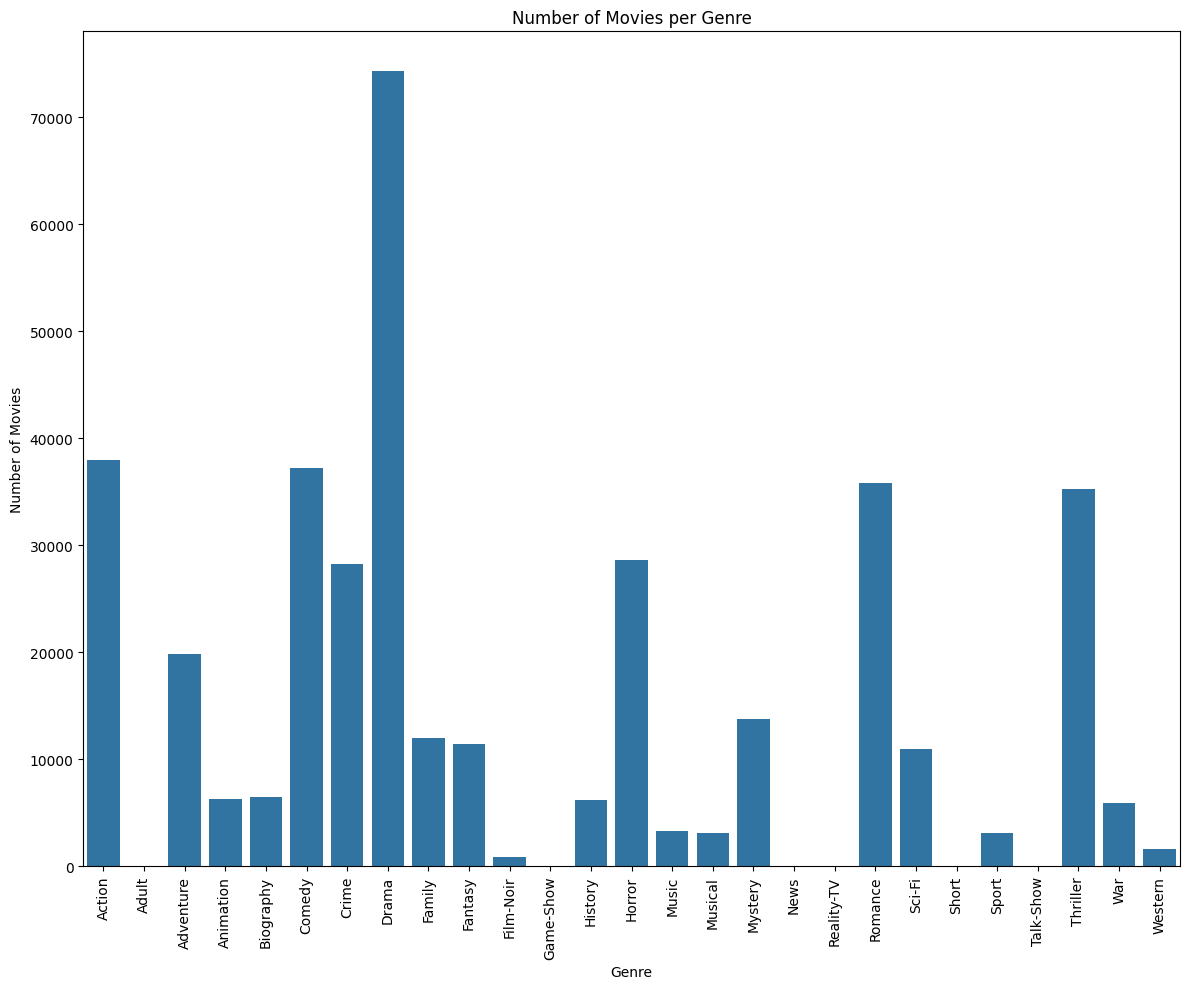

In [89]:
f, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.barplot(data=df_movies_per_genre, x='Genre', y='Total', ax=ax)
ax.set(ylabel='Number of Movies')
plt.xticks(rotation=90)
plt.title('Number of Movies per Genre')
plt.tight_layout()
plt.show()

In [90]:
print(df_movies_per_genre.sort_values(by='Total', ascending=False))

         Genre  Total
7        Drama  74337
0       Action  37986
5       Comedy  37261
19     Romance  35798
24    Thriller  35217
13      Horror  28607
6        Crime  28277
2    Adventure  19800
16     Mystery  13736
8       Family  12022
9      Fantasy  11462
20      Sci-Fi  10944
4    Biography   6439
3    Animation   6318
12     History   6140
25         War   5930
14       Music   3260
15     Musical   3141
22       Sport   3139
26     Western   1598
10   Film-Noir    891
18  Reality-TV     20
17        News     13
1        Adult      7
11   Game-Show      4
23   Talk-Show      3
21       Short      1


In [91]:
# Step 1: Define the threshold
MIN_GENRE_COUNT = 1000

# Step 2: Calculate the count of movies per genre again (if not already done)
sum_genre = final_df[category_columns].astype(int).sum()

# Step 3: Identify genres with fewer than 1000 movies
low_count_genres = sum_genre[sum_genre < MIN_GENRE_COUNT].index.tolist()

# Step 4: Drop these genre columns from the dataset
final_df = final_df.drop(columns=low_count_genres)

# Step 5: Recalculate category_columns (remaining genre columns)
category_columns = final_df.columns.drop(['movie_id', 'movie_name', 'description'])

# Step 6: Remove rows that now have **no genre assigned**
final_df = final_df[final_df[category_columns].astype(int).sum(axis=1) > 0].reset_index(drop=True)

In [92]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182207 entries, 0 to 182206
Data columns (total 23 columns):
 #   Column       Non-Null Count   Dtype   
---  ------       --------------   -----   
 0   movie_id     182207 non-null  object  
 1   movie_name   182207 non-null  object  
 2   description  182207 non-null  object  
 3   Action       182207 non-null  category
 4   Adventure    182207 non-null  category
 5   Animation    182207 non-null  category
 6   Biography    182207 non-null  category
 7   Comedy       182207 non-null  category
 8   Crime        182207 non-null  category
 9   Drama        182207 non-null  category
 10  Family       182207 non-null  category
 11  Fantasy      182207 non-null  category
 12  History      182207 non-null  category
 13  Horror       182207 non-null  category
 14  Music        182207 non-null  category
 15  Musical      182207 non-null  category
 16  Mystery      182207 non-null  category
 17  Romance      182207 non-null  category
 18  Sci-

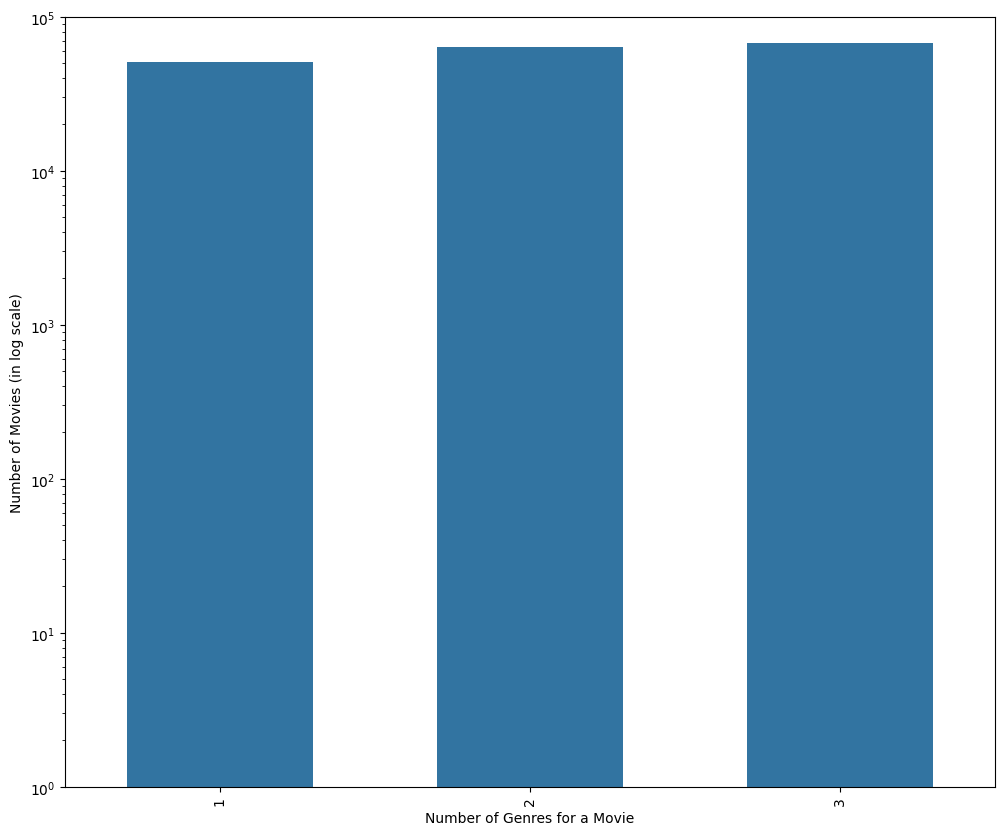

In [93]:
sum_movie = final_df[category_columns].astype(int).sum(axis=1)
df_genres_per_movie = pd.DataFrame({'movie_name': final_df.movie_name, 'num_genres': sum_movie}).groupby('num_genres').count()

f, ax = plt.subplots(1, 1, figsize=(12, 10))
sns.barplot(data=df_genres_per_movie, x=df_genres_per_movie.index, y='movie_name', ax=ax, width=0.6)  
ax.set(yscale='log', ylim=(1, 1e5), xlabel='Number of Genres for a Movie', ylabel='Number of Movies (in log scale)')
plt.xticks(rotation=90)
plt.show()


In [94]:
def remove_accents(sentence):
    cleaned_sentence = unicodedata.normalize('NFD', sentence)
    cleaned_sentence = cleaned_sentence.encode('ascii', 'ignore')
    cleaned_sentence = cleaned_sentence.decode("utf-8")
    return cleaned_sentence

In [95]:
def remove_accents(text):
    text = unicodedata.normalize('NFD', text)
    text = text.encode('ascii', 'ignore').decode("utf-8")
    return text

In [96]:
def remove_punctuation(text):
    text = re.sub(r'[?|!|\'|"|#]', '', text)
    text = re.sub(r'[,|.|;|:|(|)|{|}|\|/|<|>]|-', ' ', text)
    text = text.replace("\n", " ")
    return text

In [97]:
def keep_alpha(text):
    text = re.sub('[^a-zA-Z ]+', ' ', text)
    return text

In [98]:
def lower_case(text):
    return text.lower()

In [99]:
def lemmatize_words(sentence):
    lem = WordNetLemmatizer()
    lemmatized_words = [lem.lemmatize(word, 'v') for word in sentence.split()]
    return ' '.join(lemmatized_words)

In [100]:
def remove_stop_words(sentence):
    stop_words = set(stopwords.words('english'))
    stop_words.update(['add','plot','summary','full','see','life','story','live','find','young','one','two','love','man','become'])
    no_stop_words = [word for word in sentence.split() if word not in stop_words]
    return ' '.join(no_stop_words)

In [101]:
def text_preprocess(sentence):
    pre_processed_sentence = remove_accents(sentence)
    pre_processed_sentence = remove_punctuation(pre_processed_sentence)
    pre_processed_sentence = keep_alpha(pre_processed_sentence)
    pre_processed_sentence = lower_case(pre_processed_sentence)
    pre_processed_sentence = lemmatize_words(pre_processed_sentence)
    pre_processed_sentence = remove_stop_words(pre_processed_sentence)
    
    return pre_processed_sentence


In [102]:
final_df['description'] = final_df['description'].apply(text_preprocess)

In [103]:
def display_wordcloud_plots(data, labels):
    for col in labels:
        wordcloud = WordCloud(max_font_size=50).generate(' '.join(data[data[col] == 1]['plot']))
        plt.figure(figsize=(9, 9))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")
        plt.title(f'Movie Genre: {col}')
        plt.show()

def display_wordcloud_subplots(data, labels):
    num_cols = 2
    num_rows = math.ceil(len(labels) / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(14, 20))
    axes = axes.flatten()

    for idx, col in enumerate(labels):
        wordcloud = WordCloud(max_font_size=50).generate(' '.join(data[data[col] == 1]['plot']))
        axes[idx].imshow(wordcloud, interpolation="bilinear")
        axes[idx].axis("off")
        axes[idx].set_title(f'Movie Genre: {col}')

    for ax in axes[len(labels):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


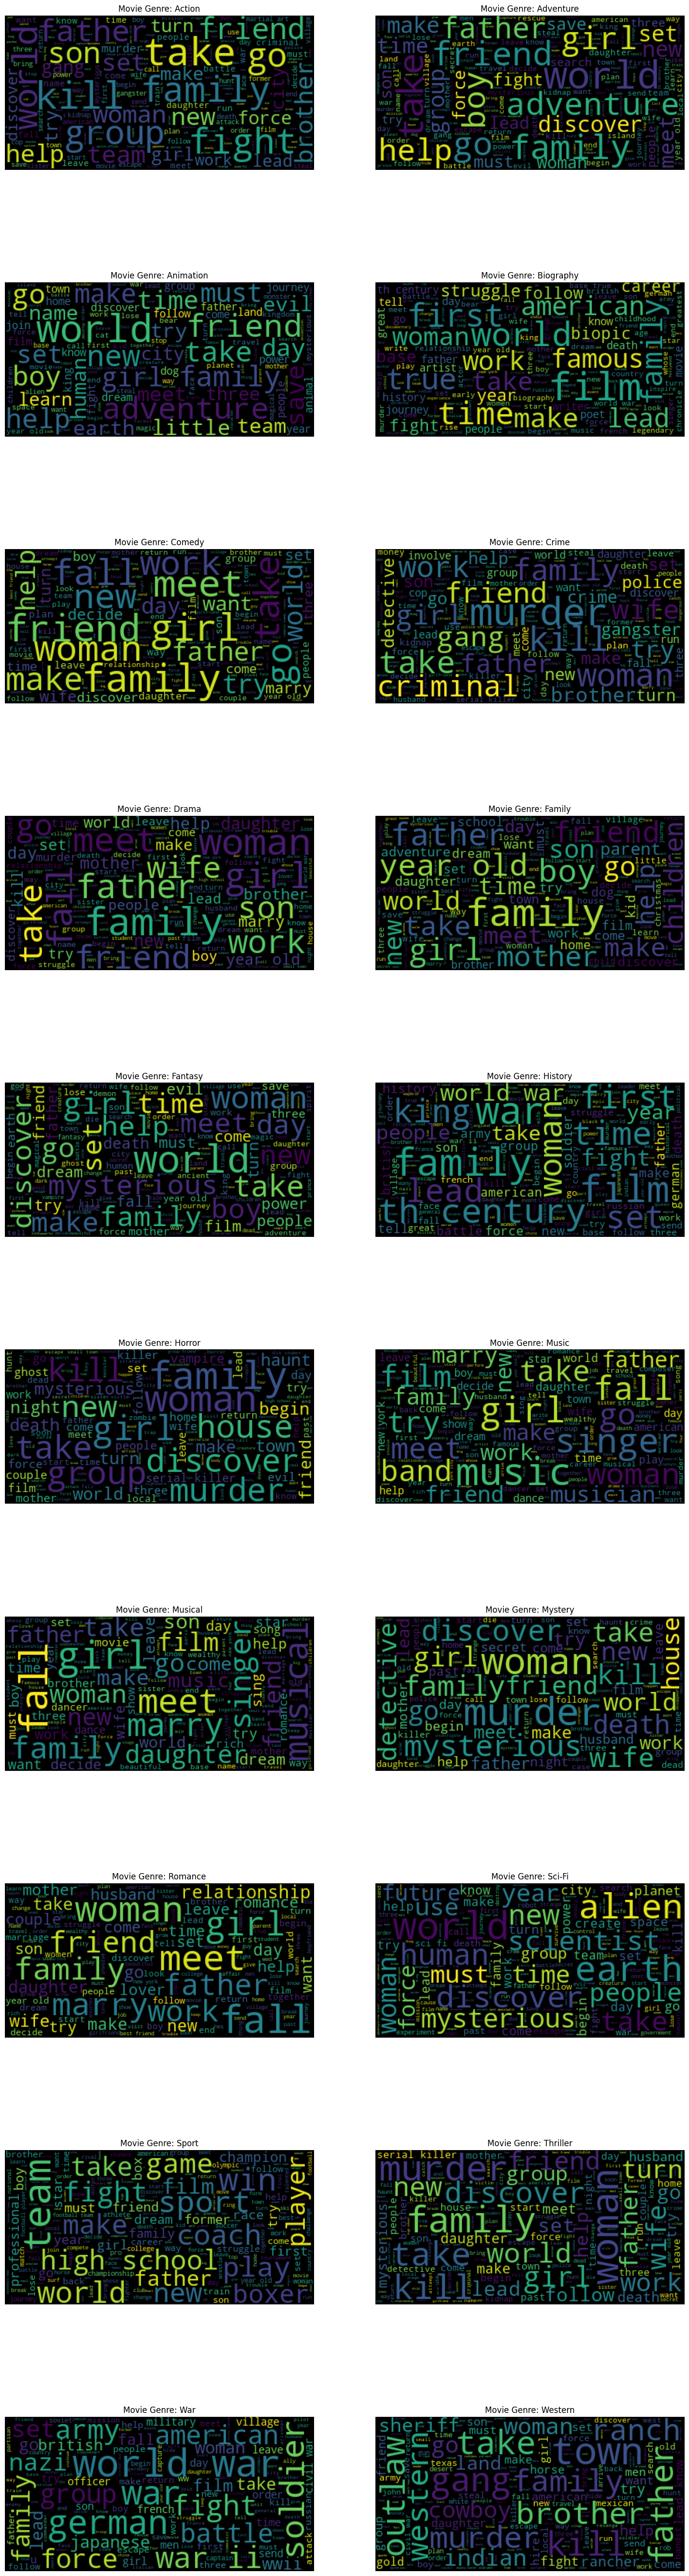

In [104]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import math

fig = plt.figure(figsize=(18, 70))
num_cols = 2
num_rows = math.ceil(len(category_columns) / num_cols)

for idx, col in enumerate(category_columns):
    wordcloud = WordCloud(max_font_size=50).generate(' '.join(final_df[final_df[col] == 1]['description']))
    ax = fig.add_subplot(num_rows, num_cols, idx + 1)
    ax.imshow(wordcloud)
    ax.axis("off")
    ax.set(title=f'Movie Genre: {col}')

plt.show()


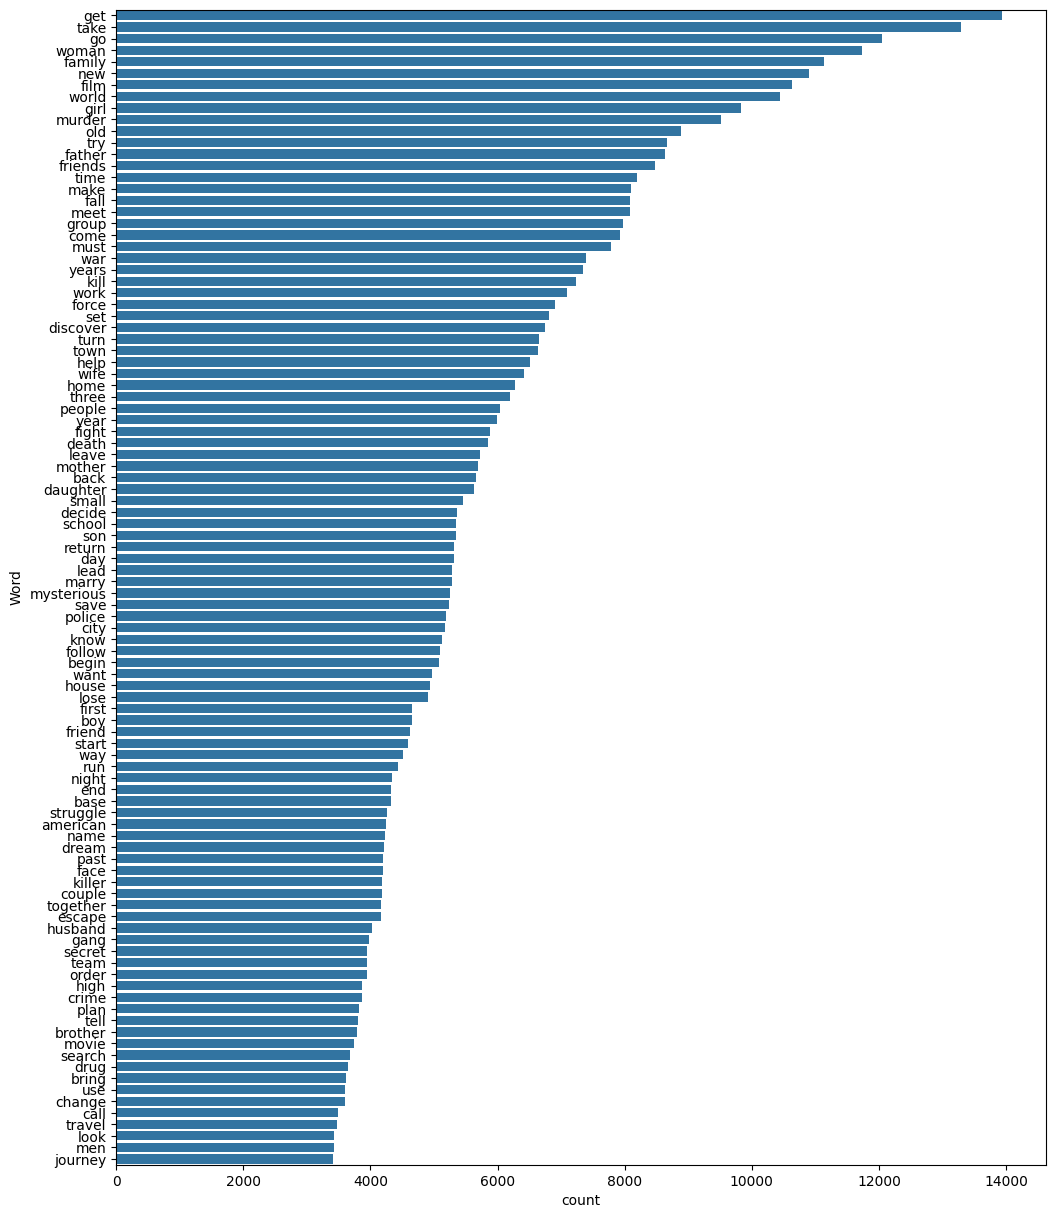

In [105]:
def freq_words(x, terms = 30): 
  all_words = ' '.join([text for text in x]) 
  all_words = all_words.split() 
  fdist = nltk.FreqDist(all_words) 
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())}) 
  
  # selecting top 20 most frequent words 
  d = words_df.nlargest(columns="count", n = terms) 
  
  # visualize words and frequencies
  plt.figure(figsize=(12,15)) 
  ax = sns.barplot(data=d, x= "count", y = "word") 
  ax.set(ylabel = 'Word') 
  plt.show()
  
# print 100 most frequent words 
freq_words(final_df['description'], 100)

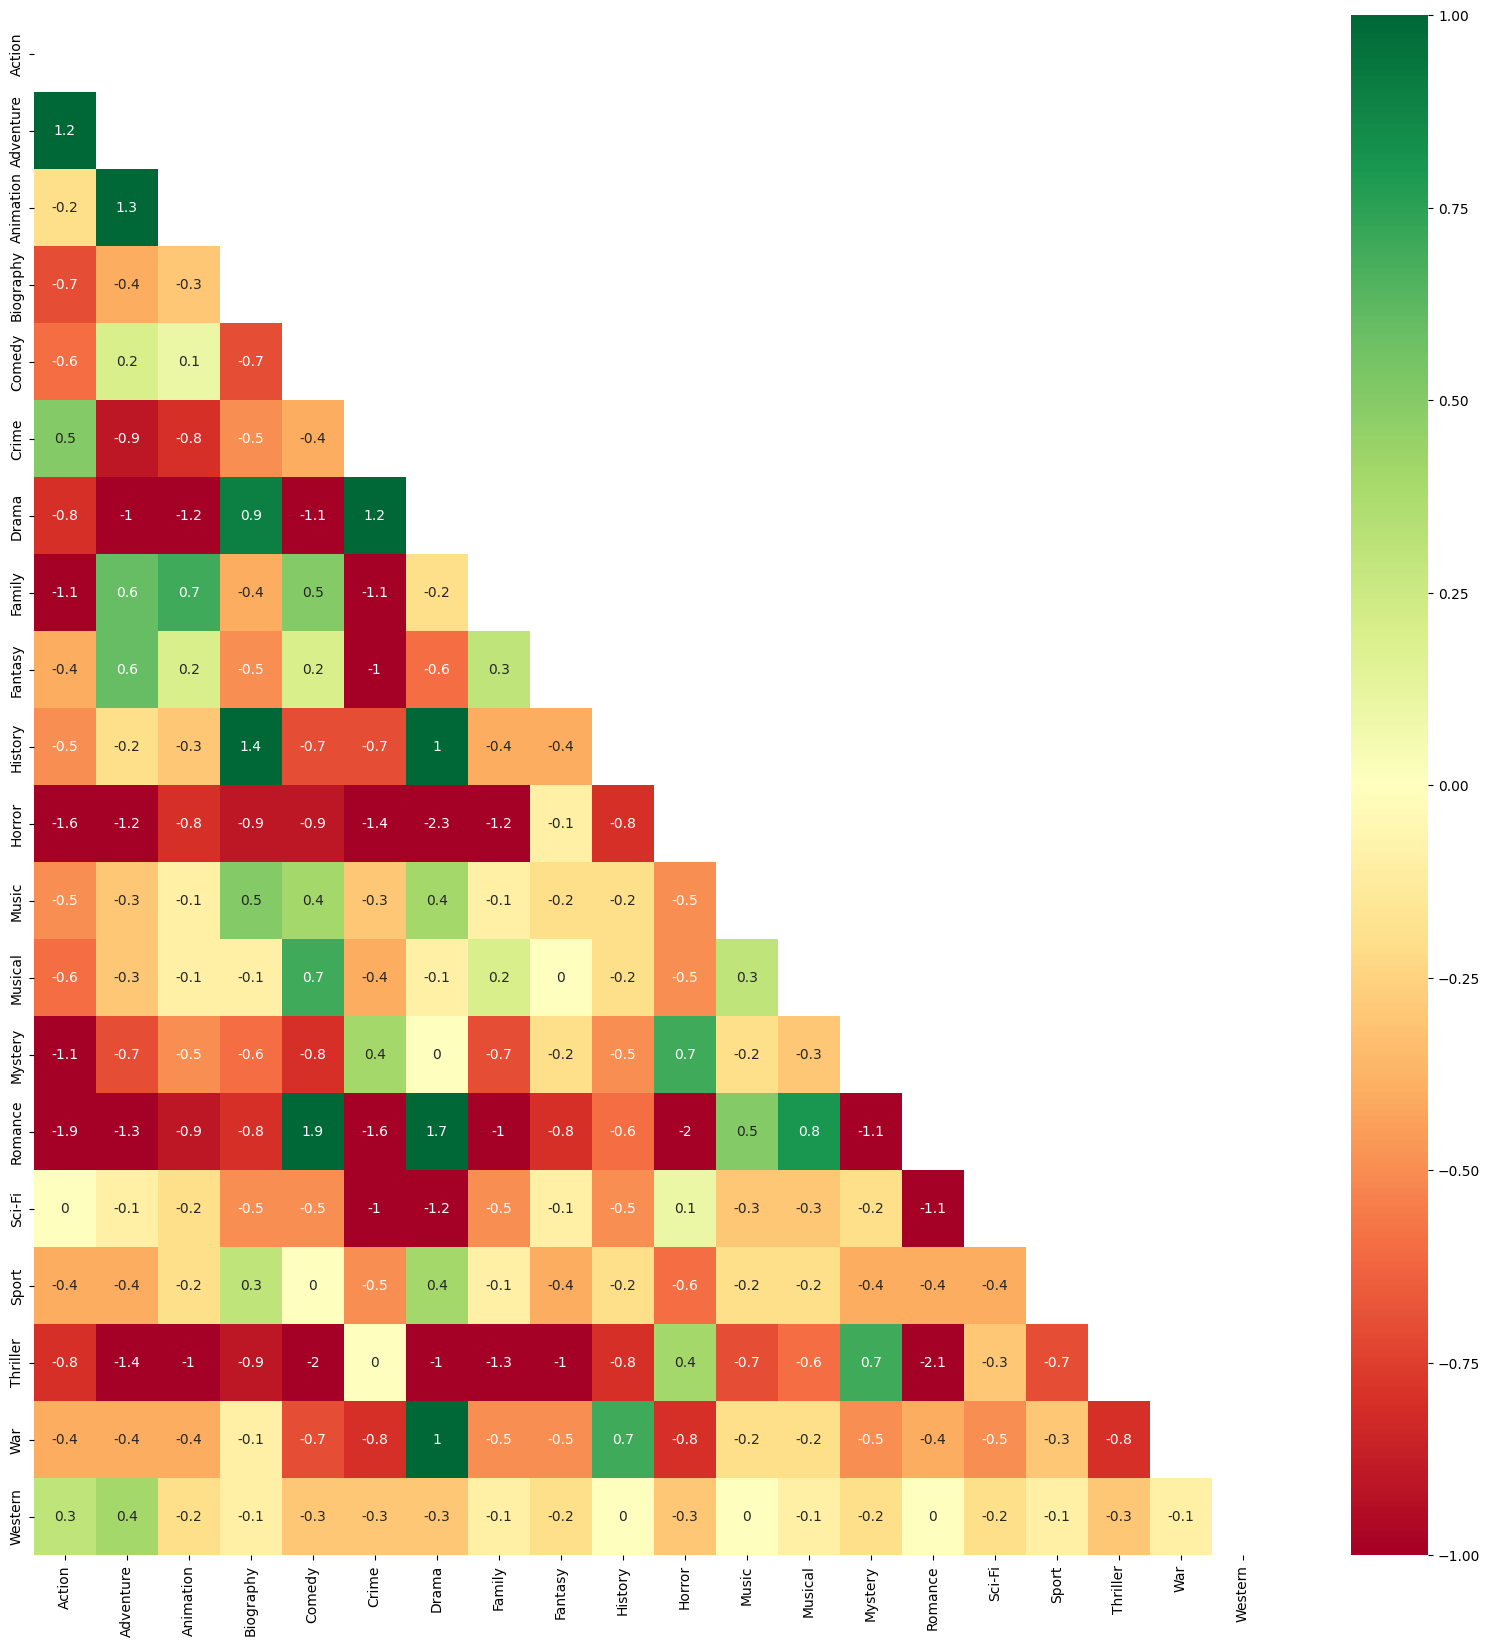

In [106]:
corr_matrix = final_df[category_columns].astype(int).corr()

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Scale correlation values for better readability
corr_matrix = (100 * corr_matrix // 1) / 10

# Plot the heatmap with the mask applied to the upper triangle (showing only lower triangle)
plt.figure(figsize=(20, 20))  # Adjust the figure size as needed
sns.heatmap(corr_matrix, mask=mask, annot=True, cbar=True, vmax=1, vmin=-1, cmap='RdYlGn')

plt.show()

In [107]:
def multi_label_train_test_split(final_df, category_columns, min_test_size=0.15, shuffle=True, random_state=29):
    data_size = final_df.shape[0]
    
    # Boolean mask for test data
    data_test_idx = np.array([False] * data_size)

    # Number of folds
    n_folds = math.floor(1 / min_test_size)
    
    # Track rows to be completely excluded
    exclude_idx = np.array([False] * data_size)

    for col in category_columns:
        # Get all rows where the label is present
        data_curr_genre = final_df[final_df[col] == 1]
        curr_genre_size = data_curr_genre.shape[0]
        
        # Compute test set size for this label
        curr_test_size = math.ceil(curr_genre_size * min_test_size)

        # KFold cross-validation
        kf = KFold(n_splits=min(n_folds, curr_genre_size), shuffle=shuffle, random_state=random_state)
        split_indices = list(kf.split(data_curr_genre))

        # Use the first fold for the test set
        test_indices = split_indices[0][1][:curr_test_size]

        # Map selected test indices to original data
        data_test_idx[data_curr_genre.iloc[test_indices].index] = True

    # Exclude rows belonging to genres that were not selected for testing
    valid_idx = ~exclude_idx

    # Split data into train and test sets
    final_test = final_df[data_test_idx & valid_idx]
    final_train = final_df[~data_test_idx & valid_idx]
    
    return final_train, final_test


In [108]:
# Running the function to get train and test datasets
final_train, final_test = multi_label_train_test_split(final_df, category_columns)

# Displaying the sizes of train and test sets
print("Train Data Shape:", final_train.shape)
print("Test Data Shape:", final_test.shape)


Train Data Shape: (131166, 23)
Test Data Shape: (51041, 23)


In [109]:
# Convert categorical columns to integers before summing
sum_genre = final_df[category_columns].astype(int).sum()
sum_genre_train = final_train[category_columns].astype(int).sum()
sum_genre_test = final_test[category_columns].astype(int).sum()

# Creating dataframes for train and test genre distributions
df_movies_per_genre_train = pd.DataFrame({'Genre': category_columns, 'Total': sum_genre_train / sum_genre, 'Data Set': 'Train'})
df_movies_per_genre_test = pd.DataFrame({'Genre': category_columns, 'Total': sum_genre_test / sum_genre, 'Data Set': 'Test'})

# Concatenating both datasets for visualization
df_movies_per_genre = pd.concat([df_movies_per_genre_train, df_movies_per_genre_test])

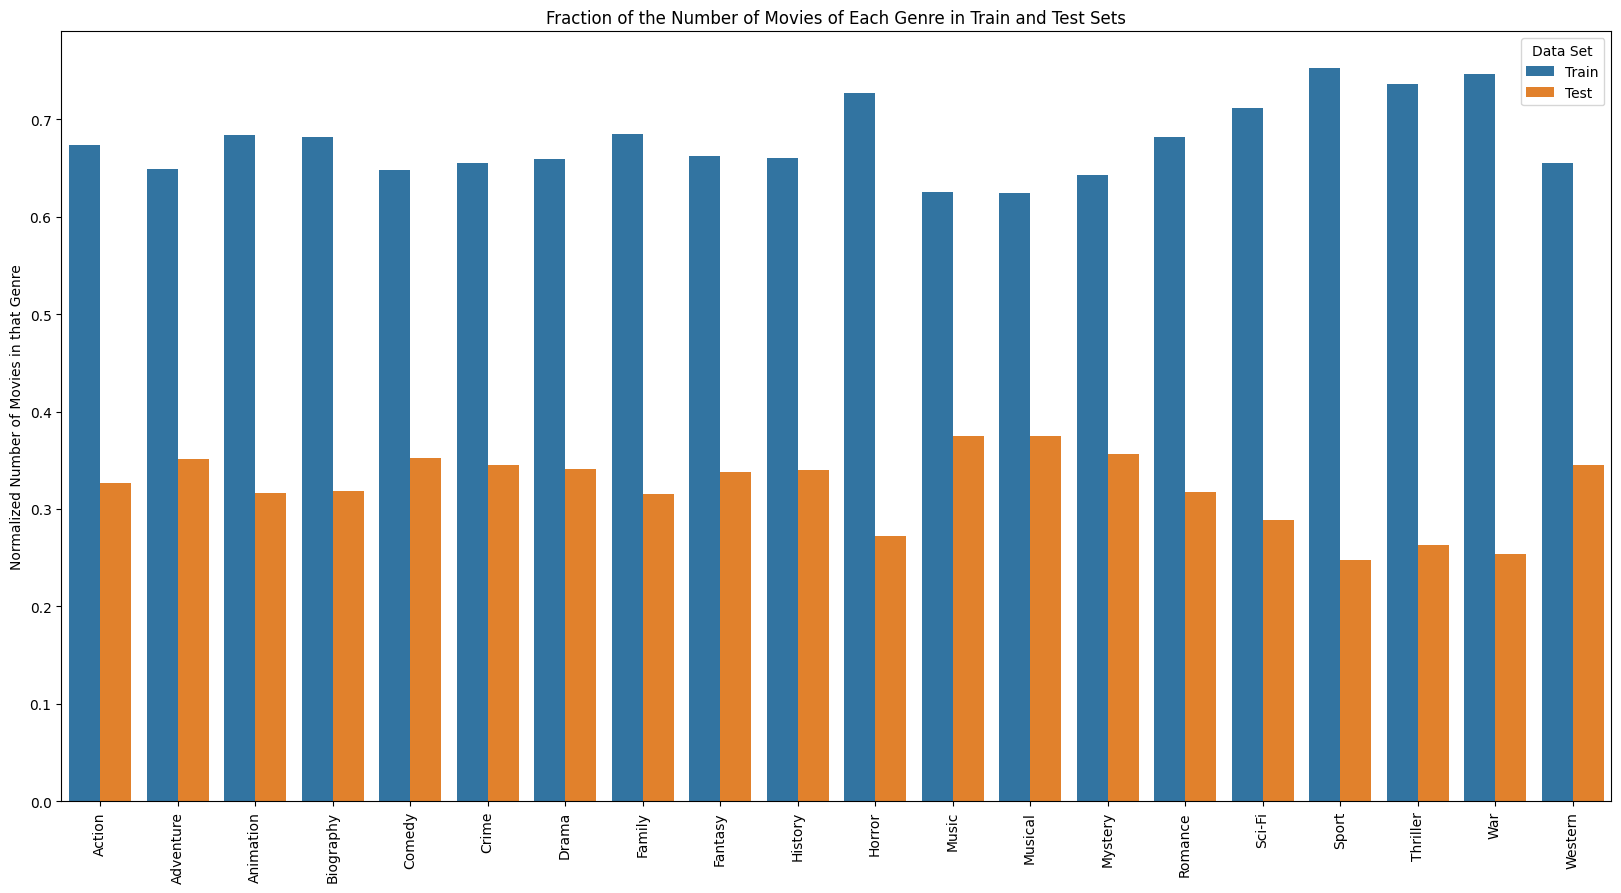

In [110]:
# Plotting the genre distribution in train and test sets
plt.figure(figsize=(20, 10))
sns.barplot(data=df_movies_per_genre, x='Genre', y='Total', hue='Data Set')
plt.ylabel('Normalized Number of Movies in that Genre')
plt.xlabel('')
plt.title('Fraction of the Number of Movies of Each Genre in Train and Test Sets')
plt.xticks(rotation=90)
plt.show()


In [111]:
from sklearn.multiclass import OneVsRestClassifier

In [112]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable


You should consider upgrading via the 'C:\Program Files\Python310\python.exe -m pip install --upgrade pip' command.


In [113]:
import xgboost as xgb
clf = OneVsRestClassifier(xgb.XGBClassifier())

In [115]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [114]:
# Enhanced TF-IDF with better parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=15000,  # Try increasing features
    min_df=5,           # Minimum document frequency
    max_df=0.8,         # Maximum document frequency
    ngram_range=(1, 2)  # Include bigrams
)

# Consider adding word embeddings
# Example with pre-trained word vectors (would require additional setup)
def get_document_vectors(texts, word_vectors):
    doc_vectors = []
    for text in texts:
        words = text.split()
        word_vecs = [word_vectors[word] for word in words if word in word_vectors]
        if word_vecs:
            doc_vectors.append(np.mean(word_vecs, axis=0))
        else:
            doc_vectors.append(np.zeros(word_vectors.vector_size))
    return np.array(doc_vectors)

In [119]:
from sklearn.linear_model import LogisticRegression

In [121]:
clf = OneVsRestClassifier(LogisticRegression(class_weight='balanced', max_iter=1000))

In [123]:
xtrain_tfidf = tfidf_vectorizer.fit_transform(final_train['description'])

# Transform the test descriptions using the same vectorizer
xtest_tfidf = tfidf_vectorizer.transform(final_test['description'])

# Print the shapes to confirm feature extraction
print("Train TF-IDF Shape:", xtrain_tfidf.shape)
print("Test TF-IDF Shape:", xtest_tfidf.shape)

Train TF-IDF Shape: (131166, 15000)
Test TF-IDF Shape: (51041, 15000)


In [124]:
from sklearn.model_selection import GridSearchCV

# Example for LogisticRegression
param_grid = {
    'estimator__C': [0.1, 1.0, 10.0],
    'estimator__solver': ['liblinear', 'saga'],
    'estimator__max_iter': [500, 1000]
}

grid_search = GridSearchCV(
    OneVsRestClassifier(LogisticRegression()),
    param_grid,
    cv=5,
    scoring='f1_micro',
    n_jobs=-1
)

grid_search.fit(xtrain_tfidf, final_train[category_columns].astype(int))
best_clf = grid_search.best_estimator_

In [126]:
clf1 = OneVsRestClassifier(LogisticRegression(max_iter=1000))


In [127]:
clf1.fit(xtrain_tfidf, final_train[category_columns].astype(int))


OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [128]:
y_pred1 = clf1.predict_proba(xtest_tfidf)

In [129]:
from sklearn.metrics import classification_report, f1_score

# More detailed evaluation
print(classification_report(final_test[category_columns].astype(int), y_pred1))

# F1 scores per class to identify problematic genres
f1_per_class = f1_score(final_test[category_columns].astype(int), y_pred1, average=None)
class_f1_df = pd.DataFrame({'Genre': category_columns, 'F1 Score': f1_per_class})
print(class_f1_df.sort_values('F1 Score'))

ValueError: Classification metrics can't handle a mix of multilabel-indicator and continuous-multioutput targets